In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [ ]:
# 1. LOAD DATA

df = pd.read_csv('SpotifyFeatures.csv')

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape          : {df.shape}")
print(f"Rows           : {df.shape[0]:,}")
print(f"Columns        : {df.shape[1]}")
print(f"\nColumn names   :\n{df.columns.tolist()}")
print(f"\nMissing values :\n{df.isnull().sum()}")
print(f"\nPopularity stats:\n{df['popularity'].describe().round(2)}")

DATASET OVERVIEW
Shape          : (232725, 18)
Rows           : 232,725
Columns        : 18

Column names   :
['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']

Missing values :
genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

Popularity stats:
count    232725.00
mean         41.13
std          18.19
min           0.00
25%          29.00
50%          43.00
75%          55.00
max         100.00
Name: popularity, dtype: float64


In [ ]:
# =============================================================================
# 2. DATA CLEANING & PREPROCESSING
# =============================================================================
print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)

# 2a. Drop the single missing track_name row
df.dropna(subset=['track_name'], inplace=True)

# 2b. Remove exact duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed : {before - len(df)}")

# 2c. Drop columns not useful for modelling
df.drop(columns=['track_id', 'artist_name', 'track_name'], inplace=True)

# 2d. Convert duration_ms → duration_sec (more interpretable)
df['duration_sec'] = df['duration_ms'] / 1000
df.drop(columns=['duration_ms'], inplace=True)

# 2e. Encode categorical columns: key, mode, time_signature, genre
cat_cols = ['key', 'mode', 'time_signature', 'genre']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f"Dataset shape after cleaning : {df.shape}")
print(f"Data types:\n{df.dtypes}")


DATA CLEANING
Duplicates removed : 0
Dataset shape after cleaning : (232724, 15)
Data types:
genre                 int64
popularity            int64
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
key                   int64
liveness            float64
loudness            float64
mode                  int64
speechiness         float64
tempo               float64
time_signature        int64
valence             float64
duration_sec        float64
dtype: object


In [ ]:
# =============================================================================
# 3. TARGET VARIABLE CREATION (percentile-based threshold)
# =============================================================================
print("\n" + "="*60)
print("TARGET VARIABLE CREATION")
print("="*60)

# Use 70th percentile as threshold (top 30% = Popular)
threshold = df['popularity'].quantile(0.70)
print(f"70th percentile popularity threshold : {threshold}")

df['popular'] = (df['popularity'] >= threshold).astype(int)

counts = df['popular'].value_counts()
print(f"\nClass distribution:")
print(f"  Not Popular (0) : {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"  Popular     (1) : {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")

# Drop raw popularity (it was used only for labelling)
df.drop(columns=['popularity'], inplace=True)


TARGET VARIABLE CREATION
70th percentile popularity threshold : 52.0

Class distribution:
  Not Popular (0) : 158,523  (68.1%)
  Popular     (1) : 74,201  (31.9%)



EXPLORATORY DATA ANALYSIS


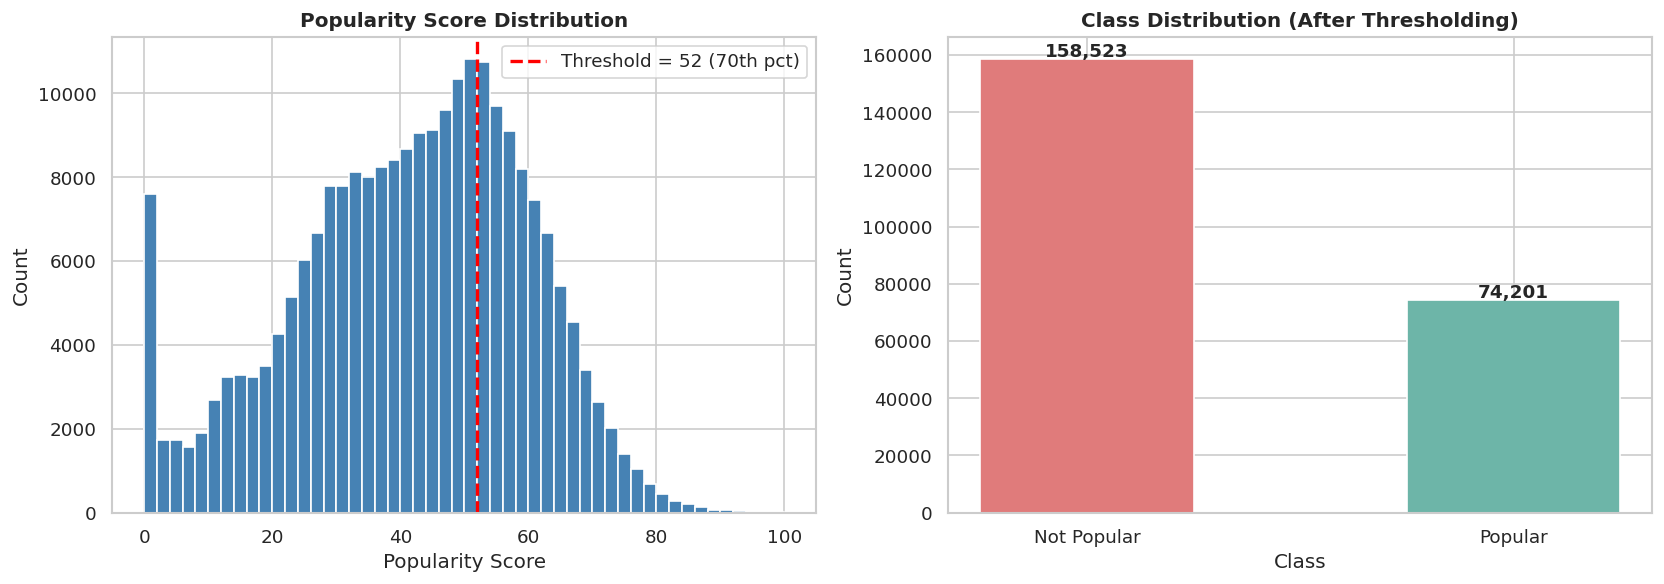

Saved: plot_01_popularity_distribution.png


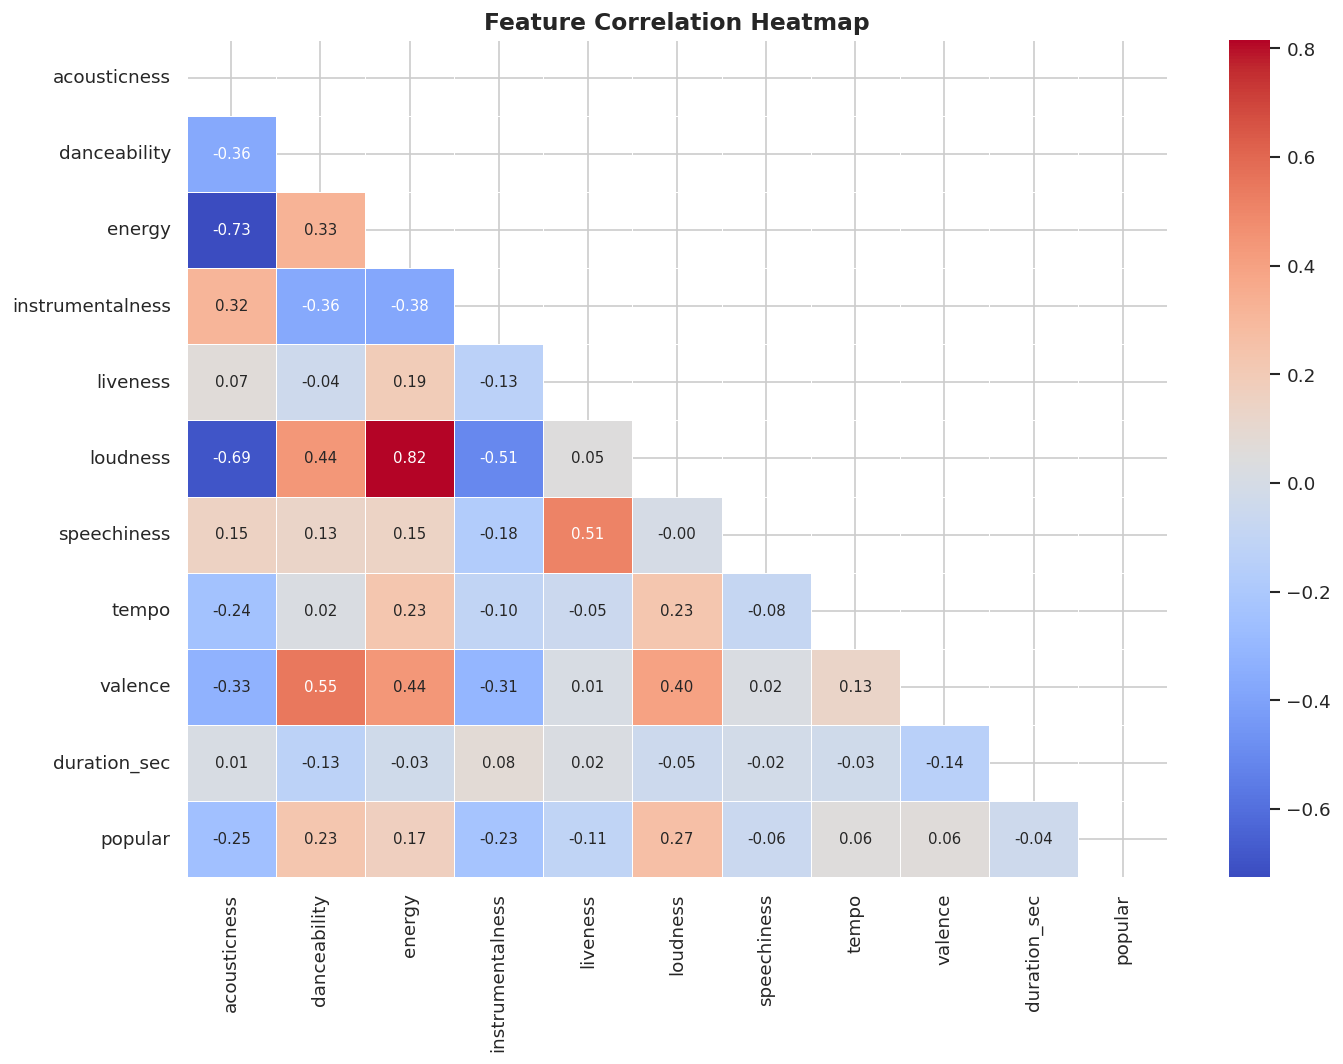

Saved: plot_02_correlation_heatmap.png


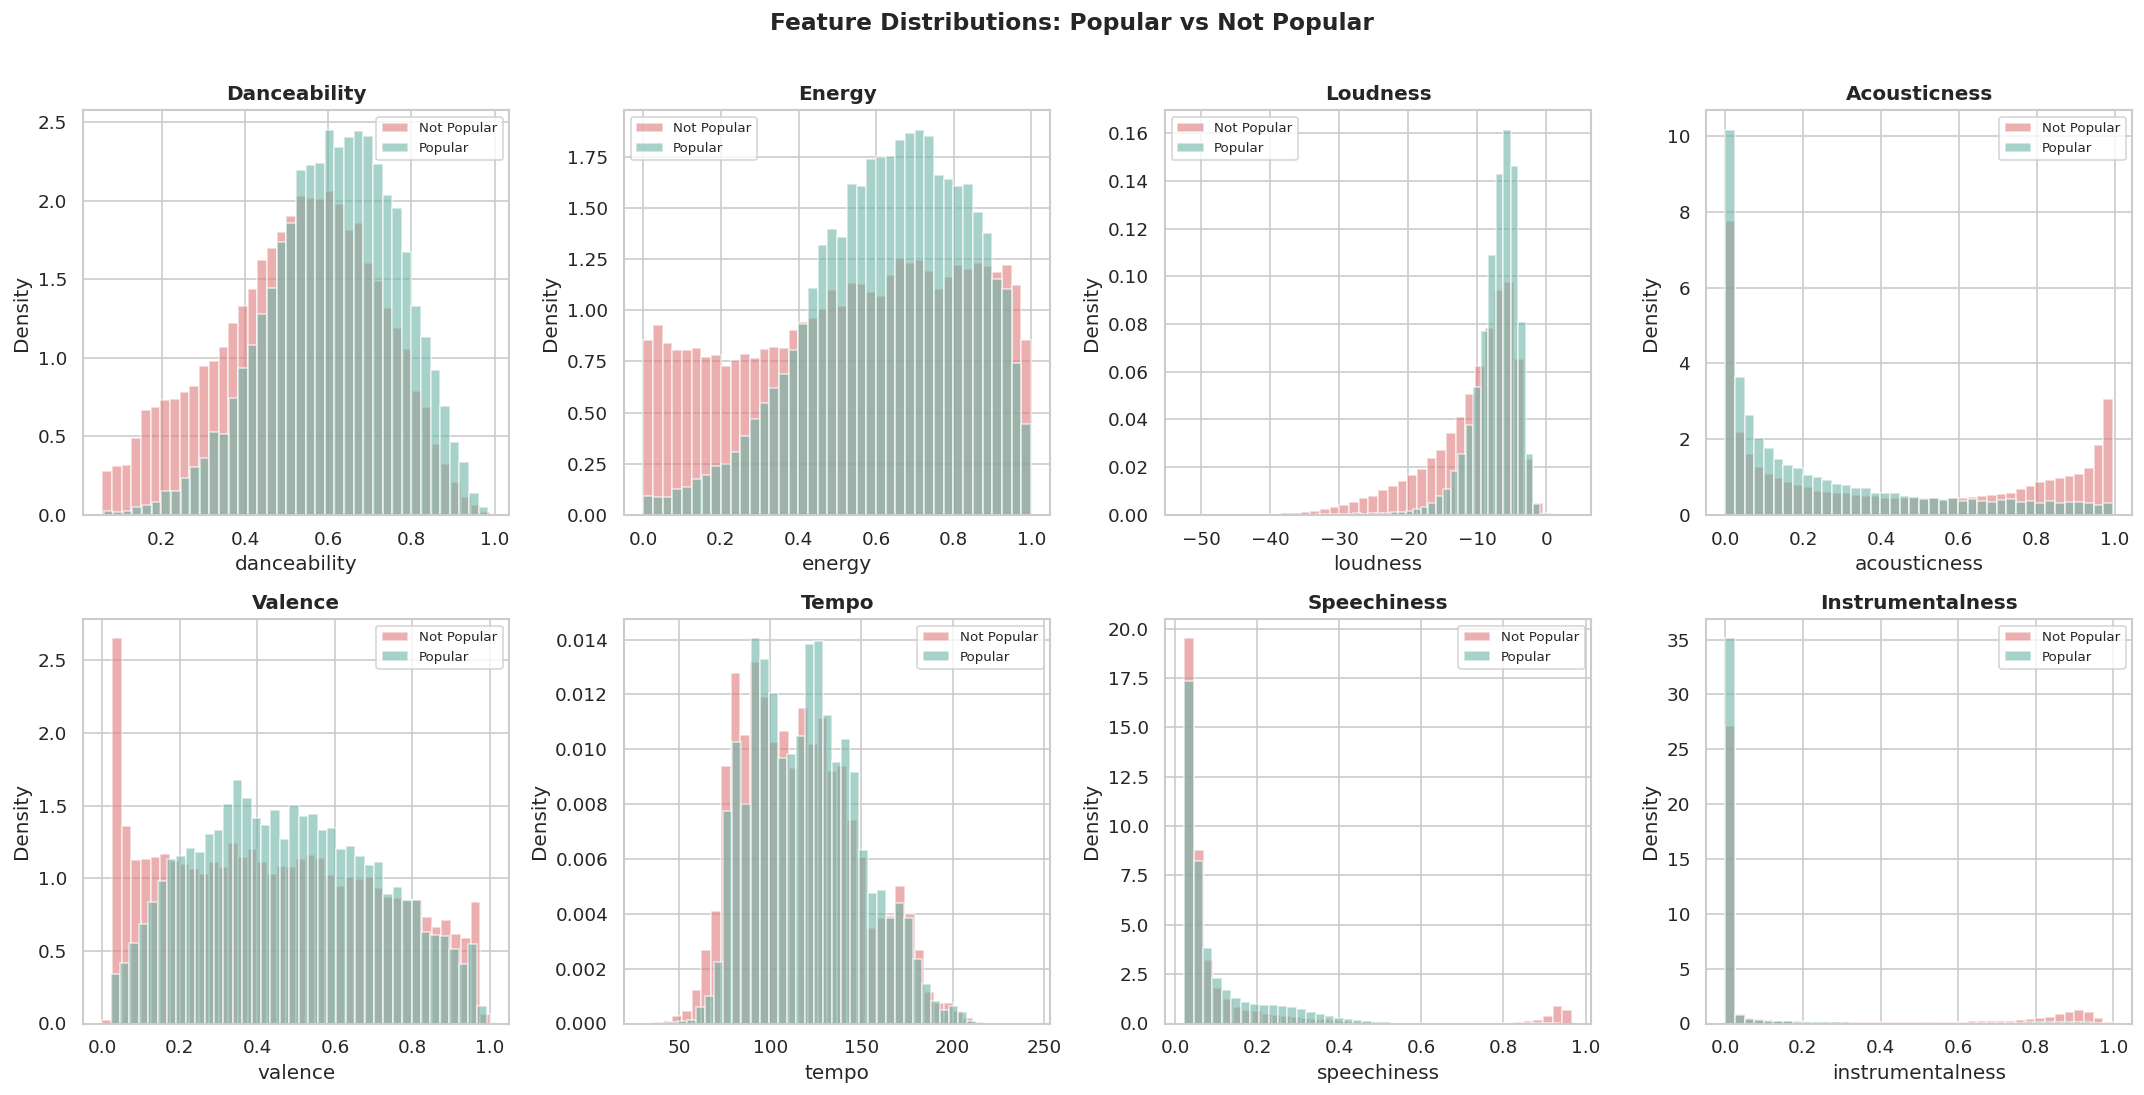

Saved: plot_03_feature_distributions.png


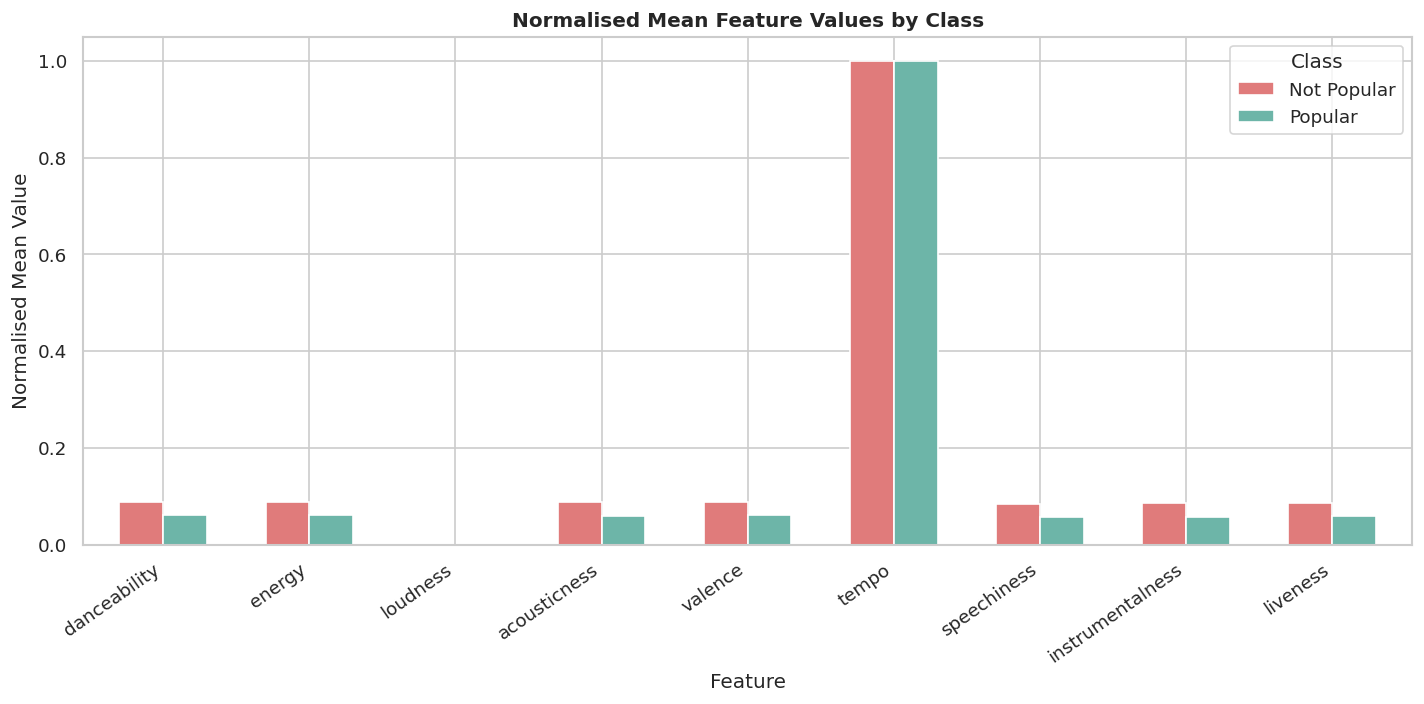

Saved: plot_04_mean_features_by_class.png


In [ ]:
# =============================================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# ── 4a. Popularity Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Re-load original popularity for distribution plot
df_orig = pd.read_csv('SpotifyFeatures.csv')
axes[0].hist(df_orig['popularity'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Threshold = {threshold:.0f} (70th pct)')
axes[0].set_title('Popularity Score Distribution', fontweight='bold')
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Class balance bar
class_labels = ['Not Popular', 'Popular']
class_counts  = [counts[0], counts[1]]
colors = ['#e07b7b', '#6db5a8']
axes[1].bar(class_labels, class_counts, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Class Distribution (After Thresholding)', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
for i, v in enumerate(class_counts):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_01_popularity_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: plot_01_popularity_distribution.png")

# ── 4b. Correlation Heatmap ───────────────────────────────────────────────────
numeric_cols = ['acousticness','danceability','energy','instrumentalness',
                'liveness','loudness','speechiness','tempo','valence',
                'duration_sec','popular']

fig, ax = plt.subplots(figsize=(12, 9))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('plot_02_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: plot_02_correlation_heatmap.png")

# ── 4c. Feature Distributions by Class ───────────────────────────────────────
features_to_plot = ['danceability','energy','loudness','acousticness',
                    'valence','tempo','speechiness','instrumentalness']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    for cls, color, label in [(0,'#e07b7b','Not Popular'), (1,'#6db5a8','Popular')]:
        axes[i].hist(df[df['popular']==cls][feat], bins=40, alpha=0.6,
                     color=color, label=label, density=True)
    axes[i].set_title(feat.capitalize(), fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Popular vs Not Popular', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_03_feature_distributions.png', bbox_inches='tight')
plt.show()
print("Saved: plot_03_feature_distributions.png")

# ── 4d. Mean feature values by class (bar chart) ─────────────────────────────
feat_cols = ['danceability','energy','loudness','acousticness',
             'valence','tempo','speechiness','instrumentalness','liveness']

means = df.groupby('popular')[feat_cols].mean().T
means.columns = ['Not Popular', 'Popular']

# Normalise for fair comparison on one axis
means_norm = (means - means.min()) / (means.max() - means.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 6))
means_norm.plot(kind='bar', ax=ax, color=['#e07b7b','#6db5a8'], edgecolor='white', width=0.6)
ax.set_title('Normalised Mean Feature Values by Class', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Normalised Mean Value')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(title='Class')
plt.tight_layout()
plt.savefig('plot_04_mean_features_by_class.png', bbox_inches='tight')
plt.show()
print("Saved: plot_04_mean_features_by_class.png")

In [ ]:
# =============================================================================
# 5. FEATURE ENGINEERING
# =============================================================================
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Interaction features
df['energy_loudness']    = df['energy'] * df['loudness']
df['dance_tempo']        = df['danceability'] * df['tempo']
df['acoustic_instrumen'] = df['acousticness'] * df['instrumentalness']

print("Added interaction features: energy_loudness, dance_tempo, acoustic_instrumen")
print(f"Final feature count: {df.shape[1] - 1}")  # exclude target


FEATURE ENGINEERING
Added interaction features: energy_loudness, dance_tempo, acoustic_instrumen
Final feature count: 17


In [ ]:
# =============================================================================
# 6. TRAIN / TEST SPLIT
# =============================================================================
print("\n" + "="*60)
print("TRAIN / TEST SPLIT")
print("="*60)

FEATURE_COLS = [c for c in df.columns if c != 'popular']
X = df[FEATURE_COLS]
y = df['popular']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]:,} samples")
print(f"Test set       : {X_test.shape[0]:,} samples")
print(f"Features used  : {X_train.shape[1]}")

# Scale features (needed for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


TRAIN / TEST SPLIT
Training set   : 186,179 samples
Test set       : 46,545 samples
Features used  : 17


In [ ]:
# =============================================================================
# 7. HANDLE CLASS IMBALANCE
# =============================================================================
class_weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
cw_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\nClass weights for imbalance handling: {cw_dict}")


Class weights for imbalance handling: {0: np.float64(0.7340401204876279), 1: np.float64(1.5681929212782804)}


In [ ]:
# =============================================================================
# 8. MODEL TRAINING
# =============================================================================
print("\n" + "="*60)
print("MODEL TRAINING")
print("="*60)

# ── Model 1: Logistic Regression ─────────────────────────────────────────────
print("\n[1/3] Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, C=1.0)
lr.fit(X_train_sc, y_train)
print("  Done.")

# ── Model 2: Random Forest ───────────────────────────────────────────────────
print("[2/3] Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("  Done.")

# ── Model 3: XGBoost ─────────────────────────────────────────────────────────
print("[3/3] Training XGBoost...")
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print("  Done.")


MODEL TRAINING

[1/3] Training Logistic Regression...
  Done.
[2/3] Training Random Forest...
  Done.
[3/3] Training XGBoost...
  Done.



MODEL EVALUATION

Model                   Accuracy  Precision   Recall       F1   ROC-AUC
----------------------------------------------------------------------
Logistic Regression       0.6388     0.4601   0.7660   0.5749    0.7363
Random Forest             0.8015     0.6430   0.8489   0.7317    0.8972
XGBoost                   0.8368     0.7008   0.8519   0.7690    0.9218


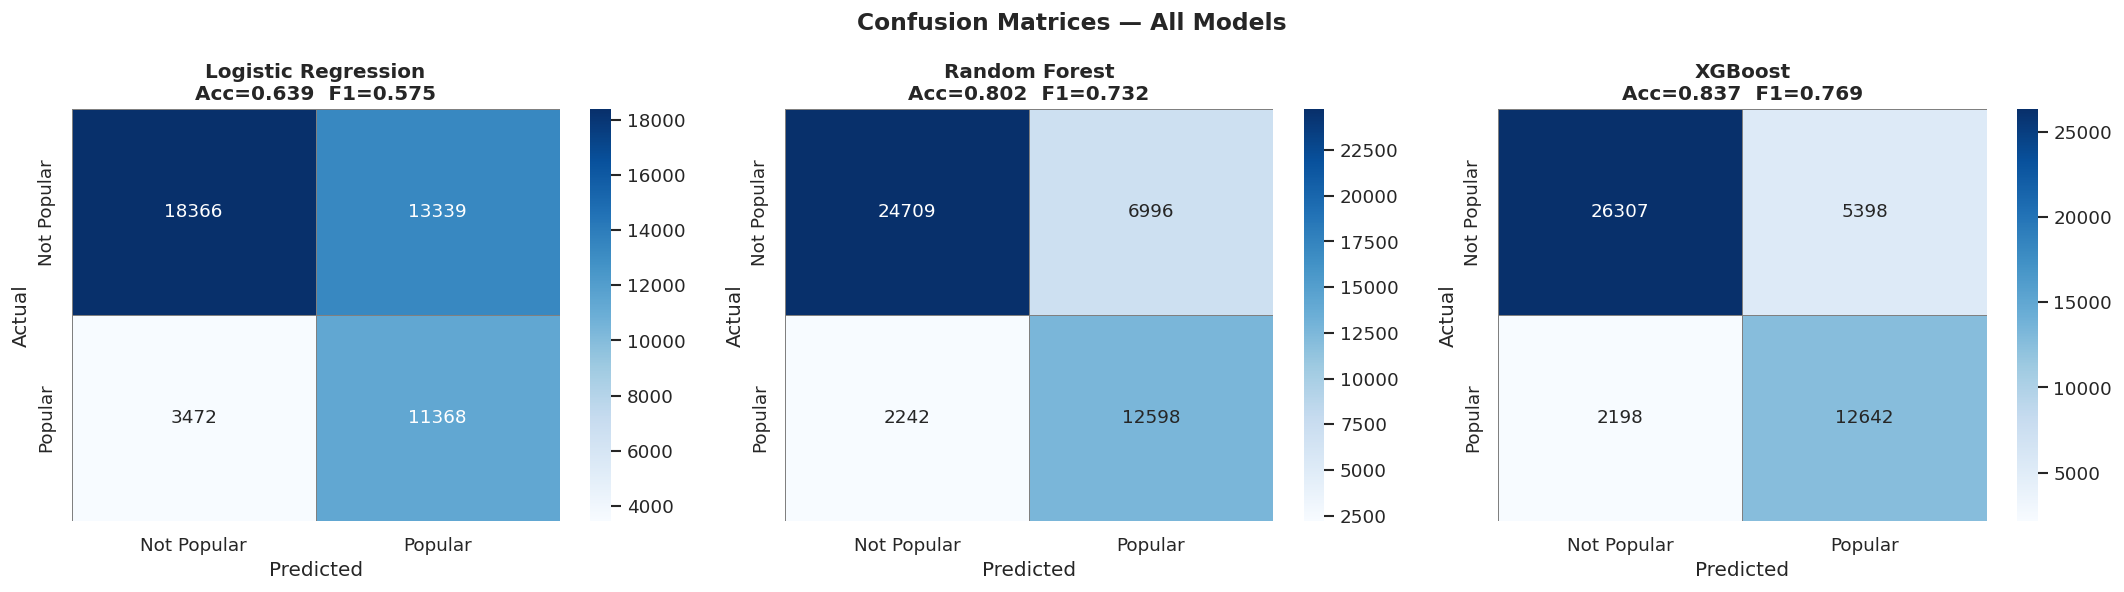

Saved: plot_05_confusion_matrices.png


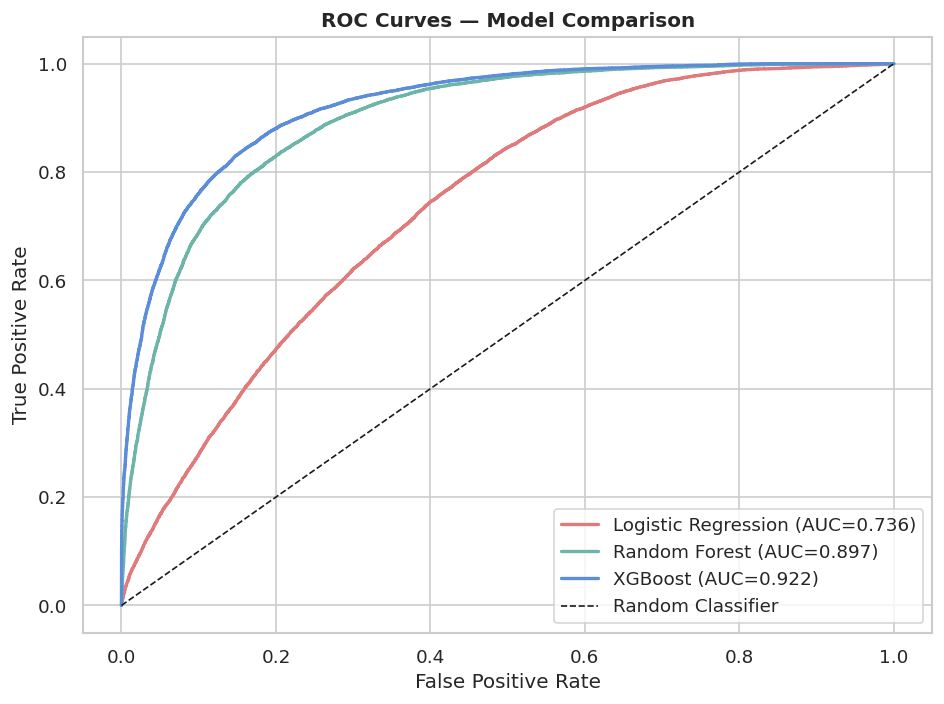

Saved: plot_06_roc_curves.png


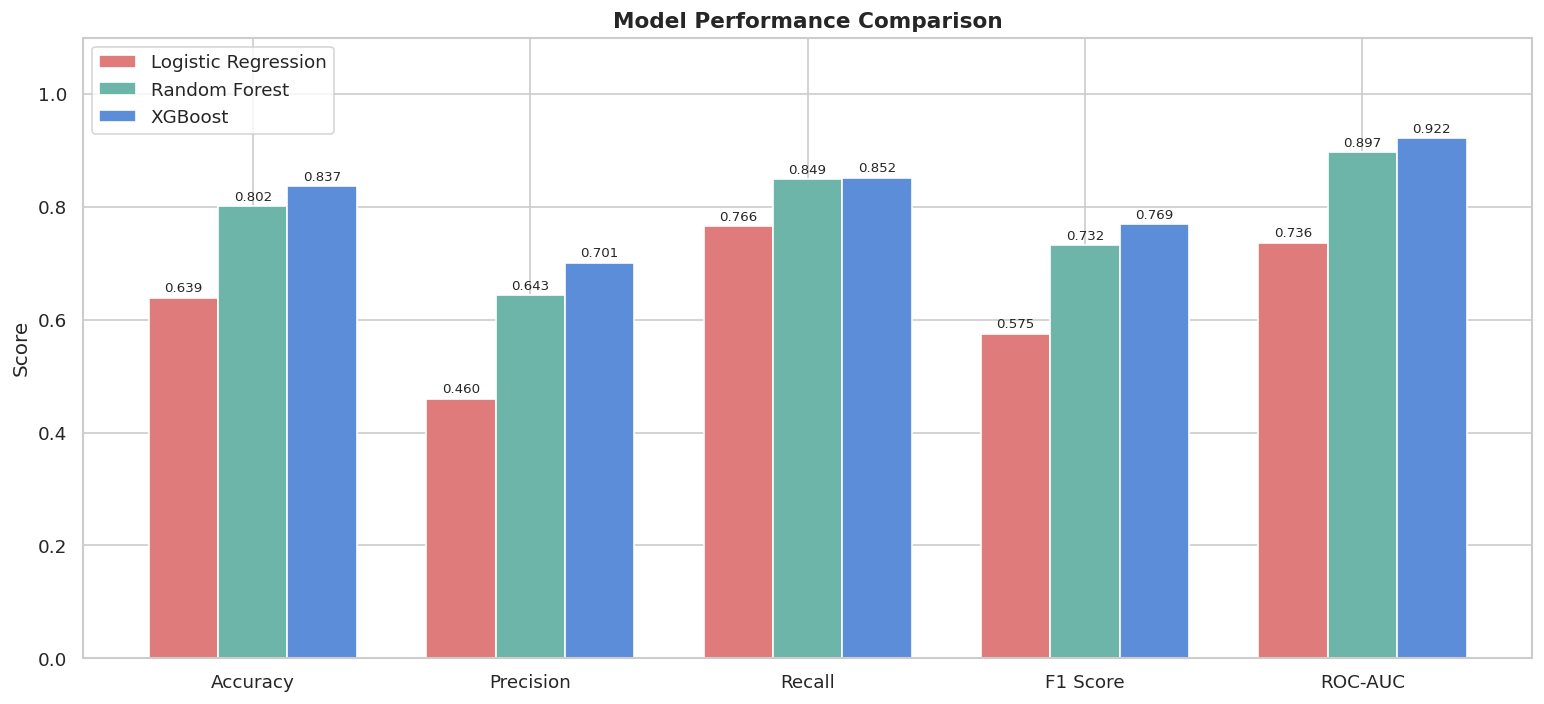

Saved: plot_07_metrics_comparison.png


In [ ]:
# =============================================================================
# 9. EVALUATION
# =============================================================================
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

models = {
    'Logistic Regression': (lr,  X_test_sc),
    'Random Forest':       (rf,  X_test),
    'XGBoost':             (xgb_model, X_test),
}

results = {}
for name, (model, X_t) in models.items():
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:,1]
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }

# Print comparison table
print(f"\n{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print("-"*70)
for name, r in results.items():
    print(f"{name:<22} {r['Accuracy']:>9.4f} {r['Precision']:>10.4f} "
          f"{r['Recall']:>8.4f} {r['F1 Score']:>8.4f} {r['ROC-AUC']:>9.4f}")

# ── 9a. Confusion Matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Popular','Popular'],
                yticklabels=['Not Popular','Popular'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'{name}\nAcc={r["Accuracy"]:.3f}  F1={r["F1 Score"]:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Saved: plot_05_confusion_matrices.png")

# ── 9b. ROC Curves ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e07b7b', '#6db5a8', '#5b8dd9']
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['ROC-AUC']:.3f})", color=color, lw=2)
ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_06_roc_curves.png', bbox_inches='tight')
plt.show()
print("Saved: plot_06_roc_curves.png")

# ── 9c. Metrics Comparison Bar Chart ─────────────────────────────────────────
metrics = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']
model_names = list(results.keys())
x = np.arange(len(metrics))
width = 0.25
colors_bar = ['#e07b7b', '#6db5a8', '#5b8dd9']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, color) in enumerate(zip(model_names, colors_bar)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('plot_07_metrics_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: plot_07_metrics_comparison.png")


FEATURE IMPORTANCE

Top 10 features (Random Forest):
genre                 0.3775
acousticness          0.0990
loudness              0.0789
instrumentalness      0.0610
speechiness           0.0502
acoustic_instrumen    0.0460
danceability          0.0437
energy                0.0415
duration_sec          0.0406
valence               0.0330
dtype: float64


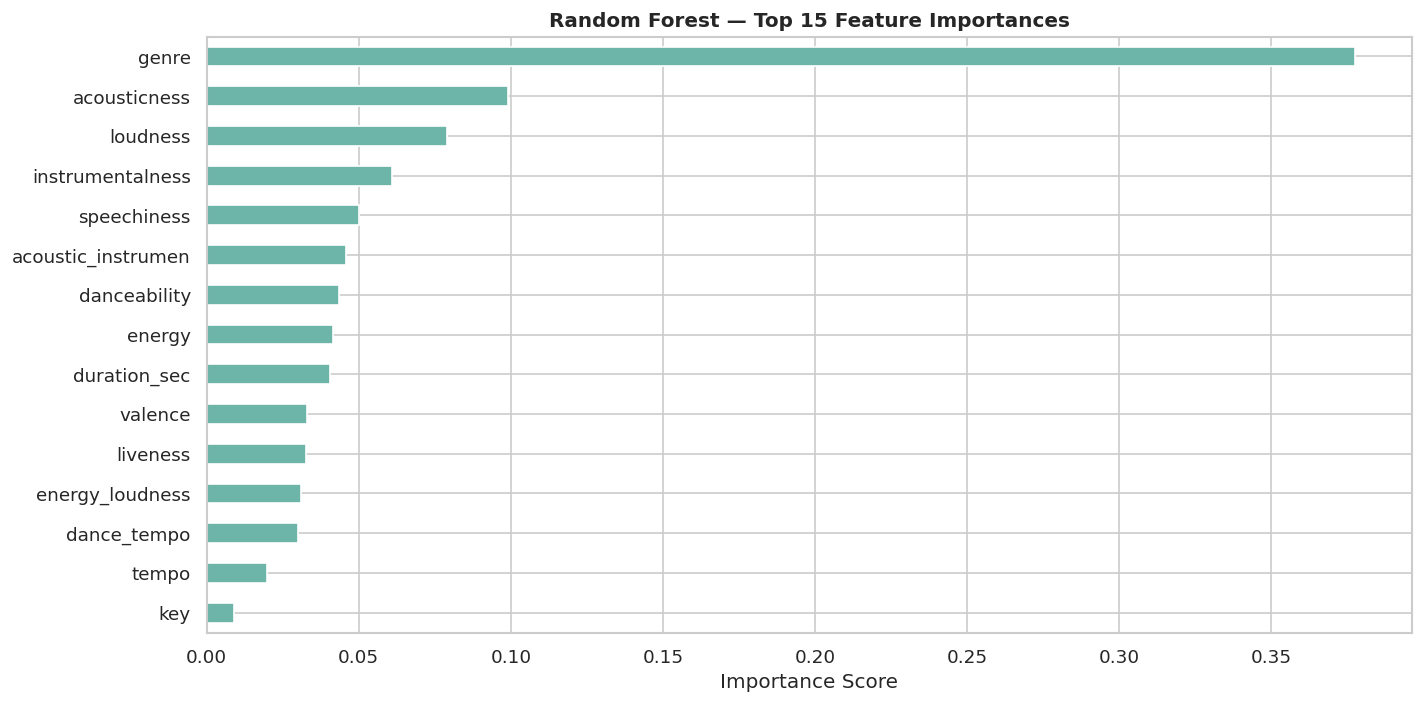

Saved: plot_08_rf_feature_importance.png

Top 10 features (XGBoost):
genre                 0.5020
loudness              0.1602
acousticness          0.0644
instrumentalness      0.0505
speechiness           0.0325
danceability          0.0221
acoustic_instrumen    0.0194
duration_sec          0.0188
energy_loudness       0.0184
liveness              0.0168
dtype: float32


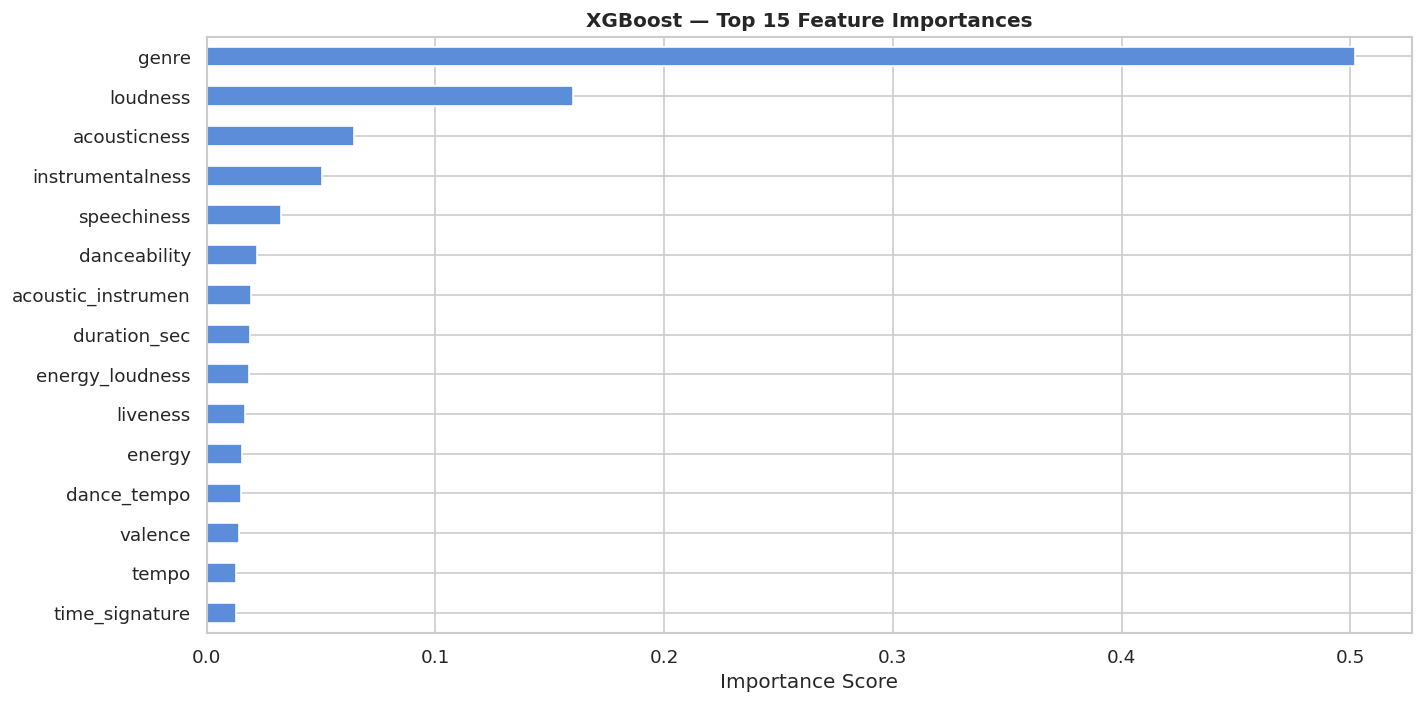

Saved: plot_09_xgb_feature_importance.png

Top 10 features (Logistic Regression |coef|):
loudness              0.9318
instrumentalness      0.6139
energy                0.4811
danceability          0.3962
acousticness          0.3872
acoustic_instrumen    0.3310
valence               0.3045
liveness              0.2139
energy_loudness       0.1203
speechiness           0.1096
dtype: float64


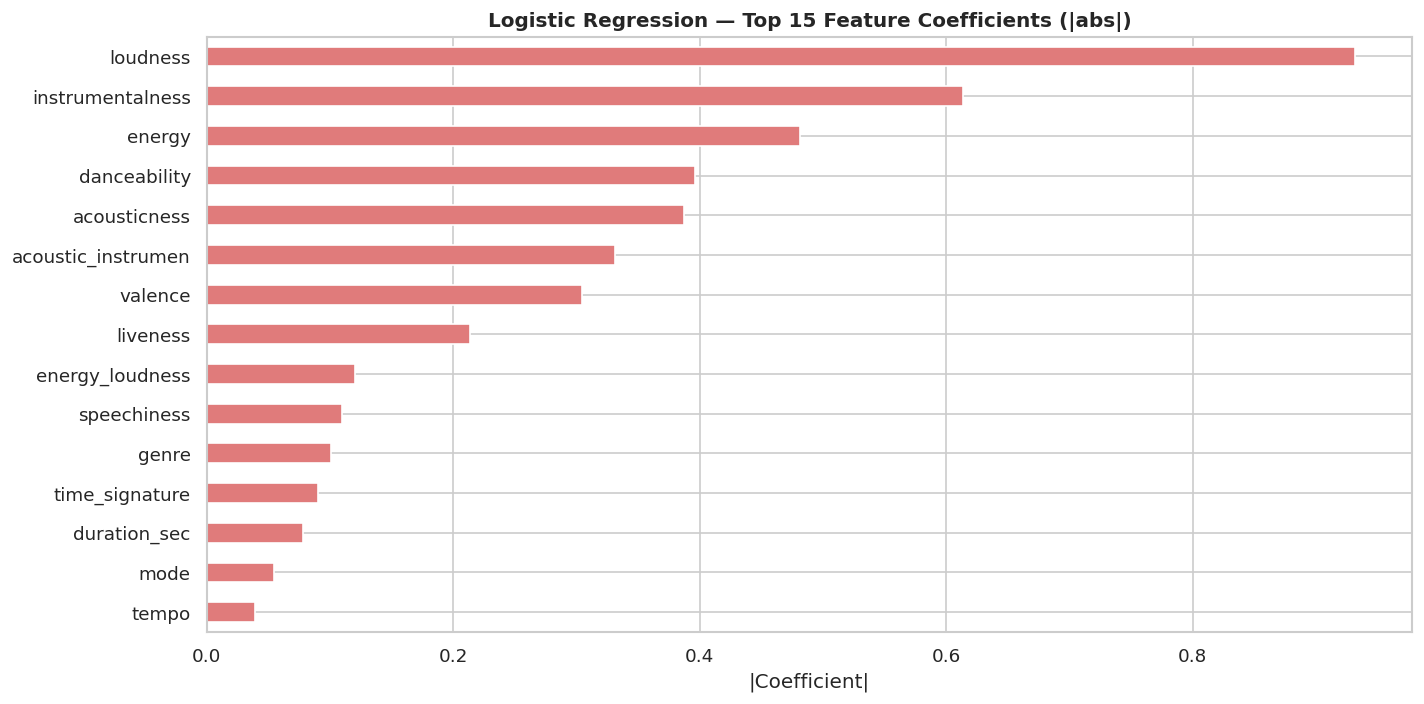

Saved: plot_10_lr_coefficients.png


In [ ]:
# =============================================================================
# 10. FEATURE IMPORTANCE
# =============================================================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

# ── 10a. Random Forest Feature Importance ────────────────────────────────────
rf_importance = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("\nTop 10 features (Random Forest):")
print(rf_importance.head(10).round(4))

fig, ax = plt.subplots(figsize=(12, 6))
rf_importance.head(15).sort_values().plot(kind='barh', color='#6db5a8', edgecolor='white', ax=ax)
ax.set_title('Random Forest — Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_08_rf_feature_importance.png', bbox_inches='tight')
plt.show()
print("Saved: plot_08_rf_feature_importance.png")

# ── 10b. XGBoost Feature Importance ─────────────────────────────────────────
xgb_importance = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("\nTop 10 features (XGBoost):")
print(xgb_importance.head(10).round(4))

fig, ax = plt.subplots(figsize=(12, 6))
xgb_importance.head(15).sort_values().plot(kind='barh', color='#5b8dd9', edgecolor='white', ax=ax)
ax.set_title('XGBoost — Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_09_xgb_feature_importance.png', bbox_inches='tight')
plt.show()
print("Saved: plot_09_xgb_feature_importance.png")

# ── 10c. Logistic Regression Coefficients ────────────────────────────────────
lr_coef = pd.Series(np.abs(lr.coef_[0]), index=FEATURE_COLS).sort_values(ascending=False)
print("\nTop 10 features (Logistic Regression |coef|):")
print(lr_coef.head(10).round(4))

fig, ax = plt.subplots(figsize=(12, 6))
lr_coef.head(15).sort_values().plot(kind='barh', color='#e07b7b', edgecolor='white', ax=ax)
ax.set_title('Logistic Regression — Top 15 Feature Coefficients (|abs|)', fontweight='bold')
ax.set_xlabel('|Coefficient|')
plt.tight_layout()
plt.savefig('plot_10_lr_coefficients.png', bbox_inches='tight')
plt.show()
print("Saved: plot_10_lr_coefficients.png")

In [ ]:
# =============================================================================
# 11. CROSS-VALIDATION
# =============================================================================
print("\n" + "="*60)
print("CROSS-VALIDATION (5-Fold Stratified)")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model, X_cv in [
    ('Logistic Regression', lr,        X_train_sc),
    ('Random Forest',       rf,        X_train),
    ('XGBoost',             xgb_model, X_train),
]:
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='f1', n_jobs=-1)
    print(f"{name:<22} | CV F1: {scores.mean():.4f} ± {scores.std():.4f}")


CROSS-VALIDATION (5-Fold Stratified)
Logistic Regression    | CV F1: 0.5774 ± 0.0034
Random Forest          | CV F1: 0.7339 ± 0.0017
XGBoost                | CV F1: 0.7681 ± 0.0018


In [ ]:
# =============================================================================
# 12. FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

best_model = max(results, key=lambda k: results[k]['F1 Score'])
print(f"\nBest model (by F1 Score): {best_model}")
print(f"  F1 Score : {results[best_model]['F1 Score']:.4f}")
print(f"  ROC-AUC  : {results[best_model]['ROC-AUC']:.4f}")
print(f"  Accuracy : {results[best_model]['Accuracy']:.4f}")

print(f"\nTop 5 most important features (Random Forest):")
for feat, score in rf_importance.head(5).items():
    print(f"  {feat:<25} : {score:.4f}")

print(f"""
KEY FINDINGS:
─────────────────────────────────────────────────────────
• Dataset            : {len(df):,} songs after cleaning
• Popularity threshold: {threshold:.0f} (70th percentile)
• Popular songs      : {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)
• Not popular songs  : {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)
• Best model         : {best_model}
• Note               : F1-score prioritised over accuracy
                       due to class imbalance handling
─────────────────────────────────────────────────────────
""")

print("All plots saved. Project complete!")


FINAL SUMMARY

Best model (by F1 Score): XGBoost
  F1 Score : 0.7690
  ROC-AUC  : 0.9218
  Accuracy : 0.8368

Top 5 most important features (Random Forest):
  genre                     : 0.3775
  acousticness              : 0.0990
  loudness                  : 0.0789
  instrumentalness          : 0.0610
  speechiness               : 0.0502

KEY FINDINGS:
─────────────────────────────────────────────────────────
• Dataset            : 232,724 songs after cleaning
• Popularity threshold: 52 (70th percentile)
• Popular songs      : 74,201 (31.9%)
• Not popular songs  : 158,523 (68.1%)
• Best model         : XGBoost
• Note               : F1-score prioritised over accuracy 
                       due to class imbalance handling
─────────────────────────────────────────────────────────

All plots saved. Project complete!
